## Radiative Heating and Precipitation Relation

### Import package

In [107]:
import numpy as np
import netCDF4 as nc

from typing import List
from pathlib import Path
from datetime import datetime
from matplotlib import pyplot as plt
from matplotlib.colors import TwoSlopeNorm

### Helper functions

In [108]:
def _convert_time(time: nc.Variable) -> List[str]:

    """
    Convert time variable from netCDF4 to a list of date strings in the format 'YYYY-MM-DD'.
    """
    dates: np.ndarray = nc.num2date(
        time[:],
        units=time.units,
        calendar=time.calendar if hasattr(time, 'calendar') else 'standard'
        )

    return [date.strftime('%Y-%m-%d') for date in dates]


def space_time_transform(
    data: np.ndarray,
    time_axis: int,
    longitude_axis: int,
) -> np.ndarray:
    """Transform data into frequency-zonal-wavenumber space.

    An inverse FFT is used in time and a forward FFT in longitude.
    NumPy's inverse FFT supplies the 1/N_time normalization; dividing
    by N_longitude completes the 2-D transform normalization.
    """
    transformed = np.fft.ifft(data, axis=time_axis)
    transformed = np.fft.fft(transformed, axis=longitude_axis)
    return transformed / data.shape[longitude_axis]


def cross_spectrum(
    data1: np.ndarray,
    data2: np.ndarray,
    time_axis: int = 0,
    longitude_axis: int = 1,
) -> np.ndarray:
    """Return S12 = F(data1) * conj(F(data2)).

    The real component is the co-spectrum and the imaginary component
    is the quadrature spectrum. Input arrays must have identical shapes.
    """
    if data1.shape != data2.shape:
        raise ValueError("Input arrays must have identical shapes.")

    spectrum1 = space_time_transform(data1, time_axis, longitude_axis)
    spectrum2 = space_time_transform(data2, time_axis, longitude_axis)
    return spectrum1 * np.conj(spectrum2)

### Load data

In [109]:
# path setting
data_path = Path("/data92/b11209013/")

# Load QR

## LW heating
with nc.Dataset(data_path / "CERES" / "column_LW_rm3harm.nc", "r") as LW_ds:

    ### Formatting time
    rad_time: List[str] = _convert_time(LW_ds.variables["time"])

    ### Load dimensions and variables
    rad_lat: np.ndarray = LW_ds.variables["lat"][:]
    rad_lon: np.ndarray = LW_ds.variables["lon"][:]

    ### Limit latitude range
    lat_mask: np.ndarray = (rad_lat >= -5.0) & (rad_lat <= 5.0)

    LW: np.ndarray = LW_ds.variables["column_LW"][:, lat_mask, :]

## SW heating
with nc.Dataset(data_path / "CERES" / "column_SW_rm3harm.nc", "r") as SW_ds:

    SW: np.ndarray = SW_ds.variables["column_SW"][:, lat_mask, :]

# Load precipitation
with nc.Dataset(data_path / "IMERG" / "DATA" / "IMERG_1deg.nc", "r") as precip_ds:

    ## Formatting time
    time_precip: List[str] = _convert_time(precip_ds.variables["time"])

    start_date: str = datetime(2006, 1, 1).strftime('%Y-%m-%d')
    end_date  : str = datetime(2018, 1, 1).strftime('%Y-%m-%d')

    mask: np.ndarray = (np.array(time_precip) >= start_date) & (np.array(time_precip) < end_date)

    ## Load dimensions and variables
    lat_precip: np.ndarray = precip_ds.variables["lat"][:]
    lon_precip: np.ndarray = precip_ds.variables["lon"][:]

    ## Limit latitude range
    lat_mask_precip: np.ndarray = (lat_precip >= -5.0) & (lat_precip <= 5.0)

    precip: np.ndarray = precip_ds.variables["precipitation"][mask, lat_mask_precip, :]

nt, ny, nx = LW.shape

### Preprocessing

In [110]:
# symmetrize data along equator
Qr: np.ndarray = LW + SW

Qr_sym: np.ndarray = (Qr + np.flip(Qr, axis=1)) / 2
LW_sym: np.ndarray = (LW + np.flip(LW, axis=1)) / 2
SW_sym: np.ndarray = (SW + np.flip(SW, axis=1)) / 2
precip_sym: np.ndarray = (precip + np.flip(precip, axis=1)) / 2

# chunking data to 96 days chunk
chunk_size: int = 96
overlay   : int = int(chunk_size // 2)

hanning_window: np.ndarray = np.hanning(chunk_size)

Qr_chunk: np.ndarray = np.array([
    Qr_sym[i:i + chunk_size, :, :] * hanning_window[:, np.newaxis, np.newaxis]
    for i in range(0, Qr_sym.shape[0] - chunk_size + 1, overlay)
])

LW_chunk: np.ndarray = np.array([
    LW_sym[i:i + chunk_size, :, :] * hanning_window[:, np.newaxis, np.newaxis]
    for i in range(0, LW_sym.shape[0] - chunk_size + 1, overlay)
])

SW_chunk: np.ndarray = np.array([
    SW_sym[i:i + chunk_size, :, :] * hanning_window[:, np.newaxis, np.newaxis]
    for i in range(0, SW_sym.shape[0] - chunk_size + 1, overlay)
])

precip_chunk: np.ndarray = np.array([
    precip_sym[i:i + chunk_size, :, :] * hanning_window[:, np.newaxis, np.newaxis]
    for i in range(0, precip_sym.shape[0] - chunk_size + 1, overlay)
])

nchunk, _, ny, nx = Qr_chunk.shape

### Calculate cross spectrum

In [111]:
# wnum and freq
wnum: np.ndarray = np.fft.fftfreq(nx, d=1.0 / nx)
freq: np.ndarray = np.fft.fftfreq(chunk_size, d=1.0) 

# Correct the spectral magnitude for energy removed by the Hann window.
window_energy: float = np.mean(hanning_window**2)

# Process one segment at a time to limit memory, while vectorizing all
# latitudes. Each segment has dimensions (time, latitude, longitude).
output_shape = (nchunk, chunk_size, nx)
cross_Qr_precip = np.empty(output_shape, dtype=np.complex128)
cross_LW_precip = np.empty(output_shape, dtype=np.complex128)
cross_SW_precip = np.empty(output_shape, dtype=np.complex128)

for segment in range(nchunk):
    precip_fft = space_time_transform(
        precip_chunk[segment], time_axis=0, longitude_axis=2
    )

    for source, destination in (
        (Qr_chunk, cross_Qr_precip),
        (LW_chunk, cross_LW_precip),
        (SW_chunk, cross_SW_precip),
    ):
        source_fft = space_time_transform(
            source[segment], time_axis=0, longitude_axis=2
        )
        cross_at_latitudes = source_fft * np.conj(precip_fft)
        destination[segment] = (
            np.nanmean(cross_at_latitudes, axis=1) / window_energy
        )

print(cross_Qr_precip.shape, cross_LW_precip.shape, cross_SW_precip.shape)

(90, 96, 360) (90, 96, 360) (90, 96, 360)


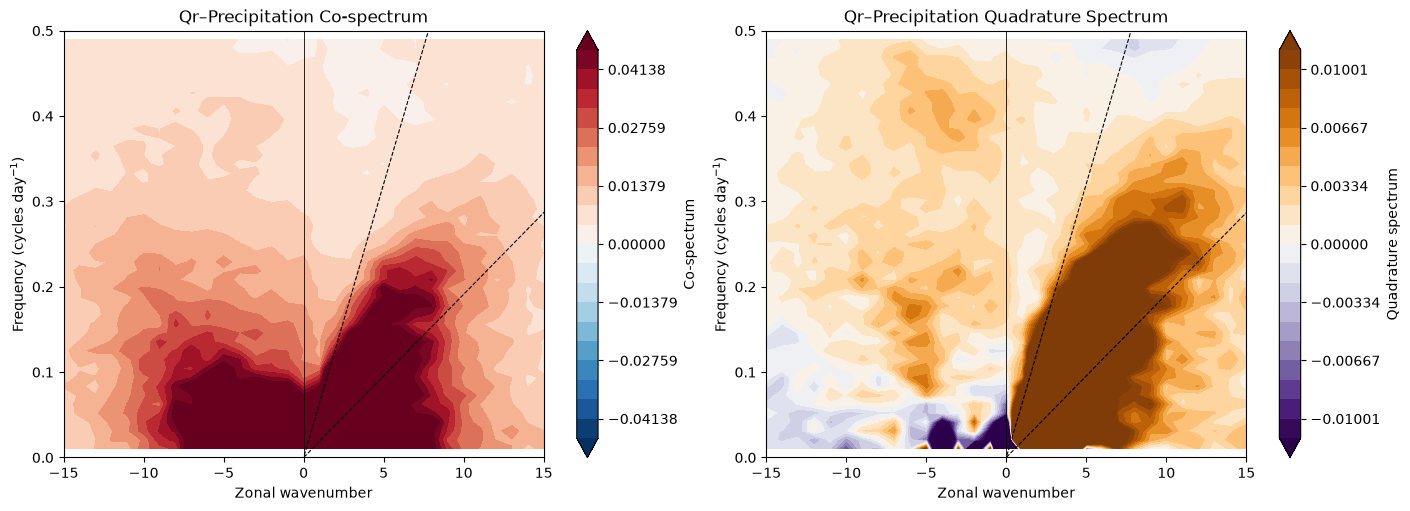

In [112]:
# Average the complex cross-spectrum across overlapping segments before
# separating it into co-spectrum and quadrature components.
mean_cross = np.nanmean(cross_Qr_precip, axis=0)
cospectrum = mean_cross.real
quadrature = mean_cross.imag
phase_degrees = np.rad2deg(np.angle(mean_cross))

# Shift both the data and coordinates so zero frequency/wavenumber align.
freq_plot = np.fft.fftshift(freq)
wnum_plot = np.fft.fftshift(wnum)
cospectrum_plot = np.fft.fftshift(cospectrum, axes=(0, 1))
quadrature_plot = np.fft.fftshift(quadrature, axes=(0, 1))

# Display positive temporal frequencies only.
positive_freq = freq_plot > 0
co_display = cospectrum_plot[positive_freq, :]
quad_display = quadrature_plot[positive_freq, :]

# Robust symmetric color ranges retain both positive and negative values.
co_limit = np.nanpercentile(np.abs(co_display), 99)
quad_limit = np.nanpercentile(np.abs(quad_display), 99)
co_levels = np.linspace(-co_limit, co_limit, 21)
quad_levels = np.linspace(-quad_limit, quad_limit, 21)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

co_cf = axes[0].contourf(
    wnum_plot, freq_plot[positive_freq], co_display,
    levels=co_levels, cmap="RdBu_r", extend="both"
)
quad_cf = axes[1].contourf(
    wnum_plot, freq_plot[positive_freq], quad_display,
    levels=quad_levels, cmap="PuOr_r", extend="both"
)

# Shallow-water dispersion lines for equivalent depths of 8 and 90 m.
for equivalent_depth in (8, 90):
    dispersion = (
        np.sqrt(9.81 * equivalent_depth)
        * wnum_plot / (2 * np.pi * 6.371e6) * 86400
    )
    for ax in axes:
        ax.plot(wnum_plot, dispersion, color="k", linestyle="--", linewidth=0.8)

axes[0].set_title("Qr–Precipitation Co-spectrum")
axes[1].set_title("Qr–Precipitation Quadrature Spectrum")
fig.colorbar(co_cf, ax=axes[0], label="Co-spectrum")
fig.colorbar(quad_cf, ax=axes[1], label="Quadrature spectrum")

for ax in axes:
    ax.axvline(0, color="k", linewidth=0.6)
    ax.set_xlim(-15, 15)
    ax.set_ylim(0, 0.5)
    ax.set_xlabel("Zonal wavenumber")
    ax.set_ylabel("Frequency (cycles day$^{-1}$)")

plt.show()